import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("./medical_data.csv")

In [ ]:
#df.head()

In [ ]:
BMI = pd.DataFrame(df['weight']/((df['height']/100)**2),columns=['IBM'],index=df.index )


In [ ]:
#df['BMI']=BMI

In [ ]:
overweight = BMI > 25
overweight = overweight.replace(to_replace = True, value = 1 )
df['overweight'] = overweight

In [ ]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0.0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1.0
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0.0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1.0
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,1.0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,1.0
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,1.0
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,1.0


In [ ]:
chol = df['cholesterol'] > 1
chol = chol.replace(to_replace=True , value= 1)
df['cholesterol']=chol

In [ ]:
gluc = df['gluc'] > 1
gluc = gluc.replace(to_replace=True , value= 1)
df['gluc']=gluc

In [ ]:
# cardio_0 = df.loc[df['cardio']==0]
# cardio_0 = cardio_0[['cholesterol','gluc','smoke','alco','overweight']]
# cardio_1 = df.loc[df['cardio']==1]
# cardio_1 = cardio_1[['cholesterol','gluc','smoke','alco','overweight']]

In [ ]:
# cardio_0 = cardio_0.melt(var_name='med_data',value_name='count')
# cardio_1 = cardio_1.melt(var_name='med_data',value_name='count')

In [ ]:
# cardio_0

In [ ]:
# cardio0_plot=sns.catplot(x='med_data',y=None,data=cardio_0,kind='count',hue='count')

In [ ]:
# cardio1_plot=sns.catplot(x='med_data',y=None,data=cardio_1,kind='count', hue='count')

In [ ]:
plot = df[['active','cholesterol','gluc','smoke','alco','cardio','overweight']]
plot = plot.melt(id_vars=['cardio'], var_name='variable', value_name='value')


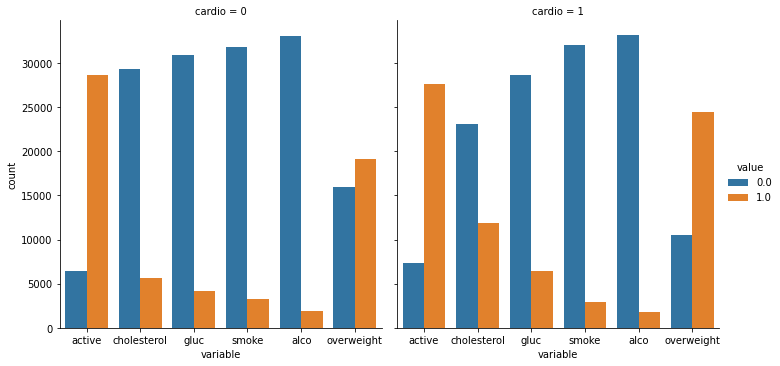

In [ ]:
g = sns.catplot(x='variable',hue='value',kind='count',data=plot,col='cardio')

In [ ]:
plot2 = df[['cholesterol','gluc','smoke','alco','cardio','overweight']]
plot2 = plot2.melt(var_name='med_data',value_name='conunt')
#plot2=plot2.groupby(['cardio'])

In [ ]:
# g = sns.FacetGrid(plot, col='cardio',hue='count')
# g.map(sns.catplot,x='med_data',y=None,data=plot,kind='count')
# plt.show()

In [ ]:
# sns.catplot(x='med_data',y=None,data=plot,kind='count',hue='count')

ValueError: ignored

In [ ]:
plot2=df[['cholesterol','gluc','smoke','alco','cardio','overweight']]
plot2=plot2.groupby(['cardio']).mean()
plot2=plot2.melt(var_name='medical_data',value_name='count')
plot2
#sns.catplot(x='medical_data',data=plot2,kind='count',hue='count')

,medical_data,count
0,cholesterol,0.162502
1,cholesterol,0.340890
2,gluc,0.117844
3,gluc,0.182795
4,smoke,0.092516
5,smoke,0.083736
6,alco,0.055424
7,alco,0.052117
8,overweight,0.545558
9,overweight,0.698705


In [ ]:
plot2.melt(plot2,var_name='med_data',value_name='count')

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resultiing Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  """Entry point for launching an IPython kernel.


,medical_data,count,med_data,count


In [ ]:
#sns.factorplot(x='med_data',y='count', data=plot,kind='bar')

In [ ]:
# sns.catplot(x='med_data',y=None,data=plot,kind='count', hue='count')

In [ ]:
df[['cholesterol','gluc','smoke','alco','cardio','overweight']]

,cholesterol,gluc,smoke,alco,cardio,overweight
0,0.0,0.0,0,0,0,0.0
1,1.0,0.0,0,0,1,1.0
2,1.0,0.0,0,0,1,0.0
3,0.0,0.0,0,0,1,1.0
4,0.0,0.0,0,0,0,0.0
...,...,...,...,...,...,...
69995,0.0,0.0,1,0,0,1.0
69996,1.0,1.0,0,0,1,1.0
69997,1.0,0.0,0,1,1,1.0
69998,0.0,1.0,0,0,1,1.0


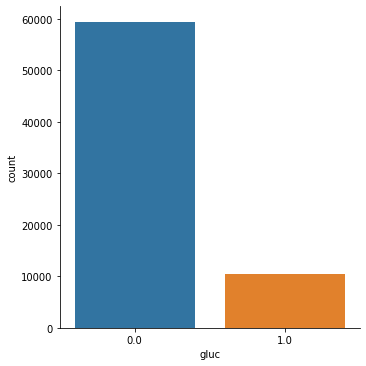

In [ ]:
sns.catplot(x='gluc' ,kind='count',data=df)

In [ ]:
#df.groupby()

In [ ]:
df.melt(value_vars=['cholesterol', 'gluc','smoke','alco','active','overweight'], id_vars=['cardio'])

In [ ]:
cardio_0 = df.loc[df['cardio']== 0]

In [ ]:
cardio_1 = df.loc[df['cardio']== 1]


##DATA CLEANING
* Clean the data. Filter out the following patient segments that represent incorrect data:
  - height is more than the 97.5th percentile
  - weight is less then the 2.5th percentile
  - weight is more than the 97.5th percentile


- diastolic pressure is higher then systolic (Keep the correct data with df['ap_lo'] <= df['ap_hi']))
- height is less than the 2.5th percentile (Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))


In [ ]:
#df = df.loc[df['ap_lo'] <= df['ap_hi']]

In [ ]:
df.loc[df['ap_lo'] > df['ap_hi']]

In [ ]:
height_up_limit = df['height'] < df['height'].quantile(0.975)
height_down_limit = df['height'] >= df['height'].quantile(0.025)
weight_up_limit = df['weight'] < df['weight'].quantile(0.975)
weight_down_limit = df['weight'] >= df['weight'].quantile(0.025)
heart_right = df['ap_lo'] <= df['ap_hi'] 


In [ ]:
df = df.loc[height_up_limit & height_down_limit & weight_up_limit & weight_down_limit & heart_right]

In [ ]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0.0,0.0,0,0,1,0,0.0
1,1,20228,1,156,85.0,140,90,1.0,0.0,0,0,1,1,1.0
2,2,18857,1,165,64.0,130,70,1.0,0.0,0,0,0,1,0.0
3,3,17623,2,169,82.0,150,100,0.0,0.0,0,0,1,1,1.0
4,4,17474,1,156,56.0,100,60,0.0,0.0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,0.0,0.0,0,0,1,1,0.0
69994,99992,21074,1,165,80.0,150,80,0.0,0.0,0,0,1,1,1.0
69995,99993,19240,2,168,76.0,120,80,0.0,0.0,1,0,1,0,1.0
69998,99998,22431,1,163,72.0,135,80,0.0,1.0,0,0,0,1,1.0


In [ ]:
corr_matrix = df.corr().round(2)
corr_matrix


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
id,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.01,0.00,-0.00
age,0.00,1.00,-0.02,-0.08,0.07,0.02,0.15,0.13,0.09,-0.04,-0.03,-0.01,0.24,0.09
gender,0.00,-0.02,1.00,0.50,0.12,0.00,0.06,-0.04,-0.02,0.34,0.17,0.01,0.00,-0.05
height,0.00,-0.08,0.50,1.00,0.24,0.00,0.01,-0.06,-0.03,0.18,0.08,-0.00,-0.02,-0.15
weight,0.00,0.07,0.12,0.24,1.00,0.03,0.23,0.13,0.10,0.05,0.06,-0.01,0.17,0.66
ap_hi,0.00,0.02,0.00,0.00,0.03,1.00,0.08,0.02,0.01,-0.00,0.00,-0.00,0.05,0.02
ap_lo,0.00,0.15,0.06,0.01,0.23,0.08,1.00,0.15,0.07,0.02,0.03,0.00,0.33,0.17
cholesterol,0.00,0.13,-0.04,-0.06,0.13,0.02,0.15,1.00,0.38,0.01,0.04,0.00,0.20,0.13
gluc,0.00,0.09,-0.02,-0.03,0.10,0.01,0.07,0.38,1.00,-0.01,0.01,-0.01,0.09,0.09
smoke,-0.00,-0.04,0.34,0.18,0.05,-0.00,0.02,0.01,-0.01,1.00,0.34,0.03,-0.02,-0.00


In [ ]:
sns.heatmap(corr_matrix)

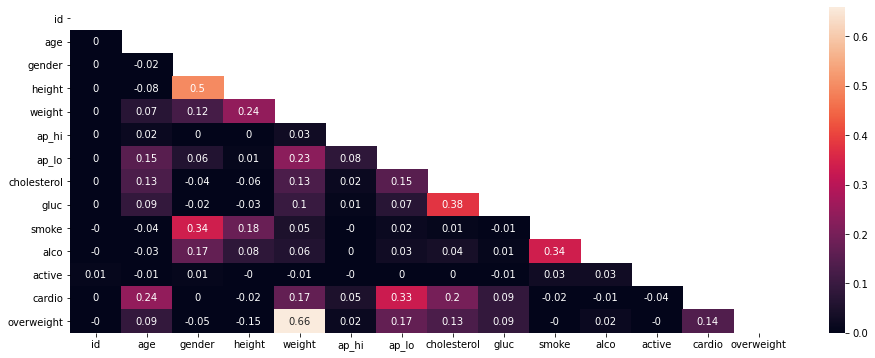

In [ ]:
plt.figure(figsize=(16, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=np.bool))
heatmap = sns.heatmap(corr_matrix, mask=mask,annot=True,vmin=0)
# heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16)
